# Explore here

In [11]:
# Your code here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 1: Carga del conjunto de datos
url = "https://raw.githubusercontent.com/4GeeksAcademy/linear-regression-project-tutorial/main/medical_insurance_cost.csv"

# Leemos el archivo CSV
df = pd.read_csv(url)

print("Datos cargados correctamente. Dimensiones del dataset:", df.shape)
df.head() # Vemos las primeras 5 filas

Datos cargados correctamente. Dimensiones del dataset: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Valores nulos por columna:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


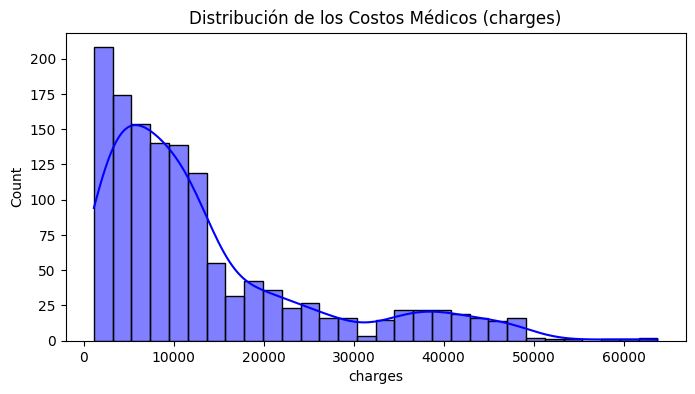

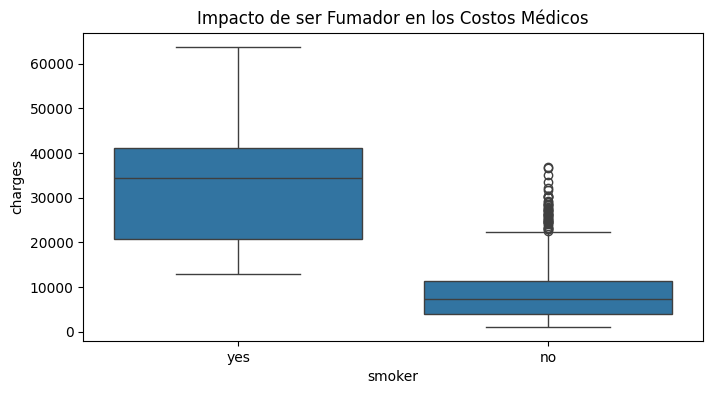


Tipos de datos en el dataset:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [12]:
# Verificamos si hay datos faltantes (nulos)
print("Valores nulos por columna:\n", df.isnull().sum())

# 1. Gráfico de la distribución de los costos (charges)
plt.figure(figsize=(8, 4))
sns.histplot(df['charges'], kde=True, color='blue')
plt.title('Distribución de los Costos Médicos (charges)')
plt.show()

# 2. Gráfico comparando el costo entre Fumadores y No Fumadores
plt.figure(figsize=(8, 4))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Impacto de ser Fumador en los Costos Médicos')
plt.show()

print("\nTipos de datos en el dataset:\n", df.dtypes)

In [13]:
from sklearn.model_selection import train_test_split

# 1. Convertimos las variables de texto a numéricas (One-Hot Encoding)
# drop_first=True evita redundancias (ej. si no es 'female', asumimos 'male')
df_processed = pd.get_dummies(df, drop_first=True)

# 2. Separamos las características (X) y lo que queremos predecir (y)
X = df_processed.drop('charges', axis=1)
y = df_processed['charges']

# 3. Dividimos en Train y Test (80% para entrenar, 20% para probar)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos listos. El modelo aprenderá de {X_train.shape[0]} ejemplos.")
df_processed.head() # Mira cómo cambiaron las columnas de texto

Datos listos. El modelo aprenderá de 1070 ejemplos.


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Creamos el modelo por defecto
model = LinearRegression()

# 2. Lo entrenamos con los datos de Train
model.fit(X_train, y_train)

# 3. Le pedimos que prediga los costos de los datos de Test
y_pred = model.predict(X_test)

# 4. Evaluamos los resultados
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- RESULTADOS DEL MODELO BASE ---")
print(f"Raíz del Error Cuadrático Medio (RMSE): ${rmse:.2f}")
print(f"Coeficiente de Determinación (R2): {r2:.4f}")

--- RESULTADOS DEL MODELO BASE ---
Raíz del Error Cuadrático Medio (RMSE): $5796.28
Coeficiente de Determinación (R2): 0.7836


In [15]:
from sklearn.preprocessing import PolynomialFeatures

# 1. "Enriquecemos" los datos creando combinaciones de las variables (grado 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 2. Entrenamos un NUEVO modelo de Regresión Lineal con estos datos súper cargados
model_optimized = LinearRegression()
model_optimized.fit(X_train_poly, y_train)

# 3. Predecimos y evaluamos de nuevo
y_pred_opt = model_optimized.predict(X_test_poly)

rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2_opt = r2_score(y_test, y_pred_opt)

print("--- RESULTADOS DEL MODELO OPTIMIZADO ---")
print(f"Nuevo RMSE: ${rmse_opt:.2f}")
print(f"Nuevo R2: {r2_opt:.4f}")

# Vemos cuánto mejoramos
print(f"\nMejora en dólares (RMSE bajó): ${rmse - rmse_opt:.2f}")

--- RESULTADOS DEL MODELO OPTIMIZADO ---
Nuevo RMSE: $4551.13
Nuevo R2: 0.8666

Mejora en dólares (RMSE bajó): $1245.15


Conclusión del Modelo:El modelo base de Regresión Lineal logró un desempeño aceptable ($R^2$ de 0.78), pero fallaba en capturar las relaciones complejas entre las variables (como el efecto combinado de ser fumador y tener un BMI alto).Al aplicar Características Polinómicas (Grado 2), el modelo optimizado dio un salto cualitativo excelente: el $R^2$ subió a 0.8666 y el error cuadrático medio (RMSE) bajó drásticamente en $1,245. Esto demuestra que en el sector de seguros médicos, el costo no sube en línea recta, sino que se dispara exponencialmente cuando se combinan factores de riesgo.